# Parte 1. Ingesta y segmentación del texto

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Pride and Prejudice.txt to Pride and Prejudice.txt


In [7]:
with open("Pride and Prejudice.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

# marcadores oficiales de Gutenberg
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker   = "*** END OF THE PROJECT GUTENBERG EBOOK"

# eliminar cabecera y pie legal
start_idx = raw_text.find(start_marker)
end_idx   = raw_text.find(end_marker)

if start_idx != -1 and end_idx != -1:
    clean_text = raw_text[raw_text.index("\n", start_idx) + 1 : end_idx].strip()
    print("cabecera y pie eliminados correctamente")
else:
    clean_text = raw_text
    print("marcadores no encontrados — revisa el archivo")

print(f"\nPrimeros 500 caracteres del texto limpio:\n{clean_text[:500]}")

cabecera y pie eliminados correctamente

Primeros 500 caracteres del texto limpio:
[Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




                                PRIDE.
                                  and
              


In [8]:
import re

clean_text = re.sub(r'\[Illustration:[^\]]*\]', '', clean_text)
clean_text = re.sub(r'\n[ \t]*\n[ \t]*\n', '\n\n', clean_text)
clean_text = clean_text.strip()

print(f"primeros 300 caracteres despues de limpiar:\n{clean_text[:300]}")

primeros 300 caracteres despues de limpiar:
PRIDE.
                                  and
                               PREJUDICE

                                  by
                             Jane Austen,

                           with a Preface by
                           George Saintsbury
                                  and
     


In [9]:
# buscar capitulos
lines = clean_text.split('\n')
chapter_lines = [(i, line.strip()) for i, line in enumerate(lines)
                 if re.search(r'chapter', line, re.IGNORECASE) and len(line.strip()) < 60]

print(f"total de lineas con 'chapter': {len(chapter_lines)}")
print("\nprimeras 20:")
for i, (num, line) in enumerate(chapter_lines[:20]):
    print(f"  linea {num:5d}: '{line}'")

total de lineas con 'chapter': 60

primeras 20:
  linea   751: 'CHAPTER II.'
  linea   864: 'CHAPTER III.'
  linea  1044: 'CHAPTER IV.'
  linea  1163: 'CHAPTER V.'
  linea  1285: 'CHAPTER VI.'
  linea  1560: 'CHAPTER VII.'
  linea  1804: 'CHAPTER VIII.'
  linea  2057: 'CHAPTER IX.'
  linea  2256: 'CHAPTER X.'
  linea  2542: 'CHAPTER XI.'
  linea  2733: 'CHAPTER XII.'
  linea  2808: 'CHAPTER XIII'
  linea  2997: 'CHAPTER XIV'
  linea  3125: 'CHAPTER XV.'
  linea  3294: 'CHAPTER XVI.'
  linea  3665: 'CHAPTER XVII.'
  linea  3802: 'CHAPTER XVIII.'
  linea  4341: 'CHAPTER XIX.'
  linea  4537: 'CHAPTER XX.'
  linea  4727: 'CHAPTER XXI.'


In [10]:
# capitulos faltantes
chapter_pattern = re.compile(
    r'^\s*(CHAPTER\s+[IVXLCDM]+\.?)\s*$',
    re.MULTILINE
)

splits = chapter_pattern.split(clean_text)

chapters = {}
for i in range(1, len(splits), 2):
    title   = splits[i].strip().rstrip('.')
    content = splits[i + 1].strip() if i + 1 < len(splits) else ""
    if len(content) > 100:
        chapters[title] = content

print(f"capitulos encontrados: {len(chapters)}")
for title in list(chapters.keys()):
    print(f"  - {title}: {len(chapters[title])} caracteres")

capitulos encontrados: 59
  - CHAPTER II: 4323 caracteres
  - CHAPTER III: 9604 caracteres
  - CHAPTER IV: 5955 caracteres
  - CHAPTER V: 5325 caracteres
  - CHAPTER VI: 13052 caracteres
  - CHAPTER VII: 11281 caracteres
  - CHAPTER VIII: 11029 caracteres
  - CHAPTER IX: 9805 caracteres
  - CHAPTER X: 12525 caracteres
  - CHAPTER XI: 8983 caracteres
  - CHAPTER XII: 3964 caracteres
  - CHAPTER XIII: 9515 caracteres
  - CHAPTER XIV: 6480 caracteres
  - CHAPTER XV: 9826 caracteres
  - CHAPTER XVI: 19098 caracteres
  - CHAPTER XVII: 7312 caracteres
  - CHAPTER XVIII: 29208 caracteres
  - CHAPTER XIX: 10705 caracteres
  - CHAPTER XX: 9223 caracteres
  - CHAPTER XXI: 11331 caracteres
  - CHAPTER XXII: 10031 caracteres
  - CHAPTER XXIII: 9358 caracteres
  - CHAPTER XXIV: 10867 caracteres
  - CHAPTER XXV: 8621 caracteres
  - CHAPTER XXVI: 12993 caracteres
  - CHAPTER XXVII: 7241 caracteres
  - CHAPTER XXVIII: 8258 caracteres
  - CHAPTER XXIX: 13722 caracteres
  - CHAPTER XXX: 7083 caracteres


In [11]:
def get_paragraphs(text):
    paragraphs = re.split(r'\n\s*\n', text)
    cleaned = []
    for p in paragraphs:
        p = p.strip()
        p = re.sub(r'\[Illustration[^\]]*\]', '', p).strip()
        if len(p) > 20:  # ignorar fragmentos muy cortos
            cleaned.append(p)
    return cleaned

chapter_paragraphs = {title: get_paragraphs(content)
                      for title, content in chapters.items()}

example_chapter = list(chapter_paragraphs.keys())[0]
print(f"capitulo: {example_chapter}")
print(f"parrafos: {len(chapter_paragraphs[example_chapter])}")
print(f"\nprimer parrafo:\n{chapter_paragraphs[example_chapter][0]}")

capitulo: CHAPTER II
parrafos: 27

primer parrafo:
Mr. Bennet was among the earliest of those who waited on Mr. Bingley. He
had always intended to visit him, though to the last always assuring his
wife that he should not go; and till the evening after the visit was
paid she had no knowledge of it. It was then disclosed in the following
manner. Observing his second daughter employed in trimming a hat, he
suddenly addressed her with,--


In [12]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

def get_sentences(text):
    return sent_tokenize(text)

# oraciones por capitulo
chapter_sentences = {title: get_sentences(content)
                     for title, content in chapters.items()}
print(f"capitulo: {example_chapter}")
print(f"oraciones: {len(chapter_sentences[example_chapter])}")
print(f"\nprimeras 3 oraciones:")
for s in chapter_sentences[example_chapter][:3]:
    print(f"  → {s}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


capitulo: CHAPTER II
oraciones: 31

primeras 3 oraciones:
  → [Illustration]

Mr. Bennet was among the earliest of those who waited on Mr. Bingley.
  → He
had always intended to visit him, though to the last always assuring his
wife that he should not go; and till the evening after the visit was
paid she had no knowledge of it.
  → It was then disclosed in the following
manner.


In [13]:
import pandas as pd

rows = []
for chapter_title, paragraphs in chapter_paragraphs.items():
    for p_idx, paragraph in enumerate(paragraphs):
        sentences = sent_tokenize(paragraph)
        for s_idx, sentence in enumerate(sentences):
            rows.append({
                "chapter":    chapter_title,
                "paragraph":  p_idx + 1,
                "sentence":   s_idx + 1,
                "text":       sentence
            })

df = pd.DataFrame(rows)
print(f"df: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nresumen:")
print(f"  capitulos : {df['chapter'].nunique()}")
print(f"  parrafos  : {df.groupby('chapter')['paragraph'].max().sum()}")
print(f"  oraciones : {len(df)}")
df.head(10)

df: 5827 filas, 4 columnas

resumen:
  capitulos : 59
  parrafos  : 1984
  oraciones : 5827


,chapter,paragraph,sentence,text
0,CHAPTER II,1,1,Mr. Bennet was among the earliest of those who...
1,CHAPTER II,1,2,"He\nhad always intended to visit him, though t..."
2,CHAPTER II,1,3,It was then disclosed in the following\nmanner.
3,CHAPTER II,1,4,Observing his second daughter employed in trim...
4,CHAPTER II,2,1,"“I hope Mr. Bingley will like it, Lizzy.”"
5,CHAPTER II,3,1,“We are not in a way to know _what_ Mr. Bingle...
6,CHAPTER II,4,1,"“But you forget, mamma,” said Elizabeth, “that..."
7,CHAPTER II,5,1,“I do not believe Mrs. Long will do any such t...
8,CHAPTER II,5,2,She has two nieces\nof her own.
9,CHAPTER II,5,3,"She is a selfish, hypocritical woman, and I ha..."


In [14]:
import pandas as pd

rows = []
for chapter_title, paragraphs in chapter_paragraphs.items():
    for p_idx, paragraph in enumerate(paragraphs):
        sentences = sent_tokenize(paragraph)
        for s_idx, sentence in enumerate(sentences):
            # clean saltos de linea
            sentence_clean = ' '.join(sentence.split())
            rows.append({
                "chapter":    chapter_title,
                "paragraph":  p_idx + 1,
                "sentence":   s_idx + 1,
                "text":       sentence_clean
            })

df = pd.DataFrame(rows)
print(f"df: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nresumen:")
print(f"  capítulos : {df['chapter'].nunique()}")
print(f"  parrafos  : {df.groupby('chapter')['paragraph'].max().sum()}")
print(f"  oraciones : {len(df)}")
df.head(10)

df: 5827 filas, 4 columnas

resumen:
  capítulos : 59
  parrafos  : 1984
  oraciones : 5827


,chapter,paragraph,sentence,text
0,CHAPTER II,1,1,Mr. Bennet was among the earliest of those who...
1,CHAPTER II,1,2,"He had always intended to visit him, though to..."
2,CHAPTER II,1,3,It was then disclosed in the following manner.
3,CHAPTER II,1,4,Observing his second daughter employed in trim...
4,CHAPTER II,2,1,"“I hope Mr. Bingley will like it, Lizzy.”"
5,CHAPTER II,3,1,“We are not in a way to know _what_ Mr. Bingle...
6,CHAPTER II,4,1,"“But you forget, mamma,” said Elizabeth, “that..."
7,CHAPTER II,5,1,“I do not believe Mrs. Long will do any such t...
8,CHAPTER II,5,2,She has two nieces of her own.
9,CHAPTER II,5,3,"She is a selfish, hypocritical woman, and I ha..."


In [15]:
df.to_csv("pride_prejudice_segmented.csv", index=False, encoding="utf-8")
print("Archivo guardado: pride_prejudice_segmented.csv")

df.groupby("chapter").agg(
    paragraphs=("paragraph", "max"),
    sentences=("sentence", "sum")
).reset_index().head(10)

Archivo guardado: pride_prejudice_segmented.csv


,chapter,paragraphs,sentences
0,CHAPTER II,27,101
1,CHAPTER III,21,278
2,CHAPTER IV,15,158
3,CHAPTER IX,39,251
4,CHAPTER L,22,271
5,CHAPTER LI,40,281
6,CHAPTER LII,35,3554
7,CHAPTER LIII,60,395
8,CHAPTER LIV,34,252
9,CHAPTER LIX,47,714


# Parte 2. Preprocesamiento con NLTK

In [16]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text: str) -> list[str]:
    """
    preprocesamiento NLP:
    1 tokenizacion a nivel palabra
    2 conversion a minusculas
    3 eliminacion de puntuacion y numeros
    4 eliminacion de stopwords
    5 lematizacion
    """
    tokens = word_tokenize(text)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

In [18]:
df['tokens'] = df['text'].apply(preprocess)
# contar tokens por oración
df['token_count'] = df['tokens'].apply(len)
print(f"Tokens totales en el libro: {df['token_count'].sum():,}")
df[['chapter', 'text', 'tokens', 'token_count']].head(5)

Tokens totales en el libro: 52,754


,chapter,text,tokens,token_count
0,CHAPTER II,Mr. Bennet was among the earliest of those who...,"[bennet, among, earliest, waited, bingley]",5
1,CHAPTER II,"He had always intended to visit him, though to...","[always, intended, visit, though, last, always...",14
2,CHAPTER II,It was then disclosed in the following manner.,"[disclosed, following, manner]",3
3,CHAPTER II,Observing his second daughter employed in trim...,"[observing, second, daughter, employed, trimmi...",8
4,CHAPTER II,"“I hope Mr. Bingley will like it, Lizzy.”","[hope, bingley, like, lizzy]",4


In [19]:
ejemplos = df[df['token_count'] > 5].sample(5, random_state=42)

print("=" * 70)
print("antes / despues")
print("=" * 70)

for _, row in ejemplos.iterrows():
    print(f"\ncapitulo: {row['chapter']}")
    print(f"  original  : {row['text']}")
    print(f"  procesado : {row['tokens']}")
    print(f"  tokens    : {len(row['tokens'])} (de ~{len(row['text'].split())} palabras)")
    print("-" * 70)

antes / despues

capitulo: CHAPTER XLVIII
  original  : Elizabeth was at no loss to understand from whence this deference for her authority proceeded; but it was not in her power to give any information of so satisfactory a nature as the compliment deserved.
  procesado : ['elizabeth', 'loss', 'understand', 'whence', 'deference', 'authority', 'proceeded', 'power', 'give', 'information', 'satisfactory', 'nature', 'compliment', 'deserved']
  tokens    : 14 (de ~35 palabras)
----------------------------------------------------------------------

capitulo: CHAPTER VI
  original  : Mary had neither genius nor taste; and though vanity had given her application, it had given her likewise a pedantic air and conceited manner, which would have injured a higher degree of excellence than she had reached.
  procesado : ['mary', 'neither', 'genius', 'taste', 'though', 'vanity', 'given', 'application', 'given', 'likewise', 'pedantic', 'air', 'conceited', 'manner', 'would', 'injured', 'higher', 'degre

In [20]:
import pandas as pd

all_tokens = [token for tokens in df['tokens'] for token in tokens]
vocab = set(all_tokens)
# palabras mas frecuentes
from collections import Counter
freq = Counter(all_tokens)
top_20 = pd.DataFrame(freq.most_common(20), columns=['palabra', 'frecuencia'])

print(f"estadisticas:")
print(f"  total de tokens      : {len(all_tokens):,}")
print(f"  vocabulario unico    : {len(vocab):,}")
print(f"  promedio tokens/oracion: {df['token_count'].mean():.1f}")
print(f"\ntop 20 palabras mas frecuentes:")
print(top_20.to_string(index=False))

estadisticas:
  total de tokens      : 52,754
  vocabulario unico    : 5,521
  promedio tokens/oracion: 9.1

top 20 palabras mas frecuentes:
  palabra  frecuencia
elizabeth         633
    could         523
    would         465
    darcy         414
     said         401
   bennet         326
     much         321
  bingley         302
     must         297
   sister         290
     jane         290
     miss         283
      one         263
     lady         262
     know         241
   though         225
    never         218
     time         216
     soon         215
     well         214


In [21]:
df['tokens_str'] = df['tokens'].apply(lambda x: ' '.join(x))
df.to_csv("pride_prejudice_preprocessed.csv", index=False, encoding="utf-8")
print("Guardado: pride_prejudice_preprocessed.csv")

Guardado: pride_prejudice_preprocessed.csv


# Parte 3. Representación vectorial del texto

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
import pandas as pd

# agrupar un documento = un capitulo
chapter_docs = df.groupby('chapter')['tokens_str'].apply(lambda x: ' '.join(x)).reset_index()
chapter_docs.columns = ['chapter', 'processed_text']

print(f"doc (capitulos): {len(chapter_docs)}")
print(chapter_docs.head())

doc (capitulos): 59
       chapter                                     processed_text
0   CHAPTER II  bennet among earliest waited bingley always in...
1  CHAPTER III  bennet however assistance five daughter could ...
2   CHAPTER IV  jane elizabeth alone former cautious praise bi...
3   CHAPTER IX  elizabeth passed chief night sister room morni...
4    CHAPTER L  bennet often wished period life instead spendi...


In [23]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(chapter_docs['processed_text'])

print("=" * 50)
print("BAG OF WORDS")
print("=" * 50)
print(f"  dimension  : {bow_matrix.shape}  →  (capitulos × terminos)")
print(f"  vocabulario  : {len(bow_vectorizer.get_feature_names_out())} palabras")
print(f"  elementos    : {bow_matrix.nnz:,} no-cero de {bow_matrix.shape[0]*bow_matrix.shape[1]:,} totales")
sparsity_bow = 1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])
print(f"  esparsidad   : {sparsity_bow:.2%}")

# Vista de la matriz (primeros 5 capítulos, 10 términos)
bow_df = pd.DataFrame(
    bow_matrix[:5, :10].toarray(),
    index=chapter_docs['chapter'][:5],
    columns=bow_vectorizer.get_feature_names_out()[:10]
)
print(f"\nMuestra de la matriz BoW:")
print(bow_df)

BAG OF WORDS
  dimension  : (59, 5520)  →  (capitulos × terminos)
  vocabulario  : 5520 palabras
  elementos    : 31,657 no-cero de 325,680 totales
  esparsidad   : 90.28%

Muestra de la matriz BoW:
             abatement  abhorrence  abhorrent  abide  abiding  ability  able  \
chapter                                                                        
CHAPTER II           0           0          0      0        0        0     0   
CHAPTER III          0           0          0      0        0        0     0   
CHAPTER IV           0           0          0      0        0        0     0   
CHAPTER IX           0           0          0      0        0        0     1   
CHAPTER L            0           0          0      0        0        0     2   

             ablution  abode  abominable  
chapter                                   
CHAPTER II          0      0           0  
CHAPTER III         0      0           0  
CHAPTER IV          0      0           0  
CHAPTER IX          0    

In [24]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(chapter_docs['processed_text'])

print("=" * 50)
print("TF-IDF")
print("=" * 50)
print(f"  dimensiones  : {tfidf_matrix.shape}  →  (capitulos × terminos)")
print(f"  vocabulario  : {len(tfidf_vectorizer.get_feature_names_out())} palabras")
print(f"  elementos    : {tfidf_matrix.nnz:,} no-cero de {tfidf_matrix.shape[0]*tfidf_matrix.shape[1]:,} totales")
sparsity_tfidf = 1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f"  esparsidad   : {sparsity_tfidf:.2%}")

print(f"\ntop 5 terminos por capitulo (TF-IDF):")
feature_names = tfidf_vectorizer.get_feature_names_out()
for i, chapter in enumerate(chapter_docs['chapter'][:5]):
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:5]
    top_terms = [(feature_names[j], round(row[j], 3)) for j in top_idx]
    print(f"  {chapter}: {top_terms}")

TF-IDF
  dimensiones  : (59, 5520)  →  (capitulos × terminos)
  vocabulario  : 5520 palabras
  elementos    : 31,657 no-cero de 325,680 totales
  esparsidad   : 90.28%

top 5 terminos por capitulo (TF-IDF):
  CHAPTER II: [('cough', np.float64(0.262)), ('bennet', np.float64(0.201)), ('nonsense', np.float64(0.196)), ('said', np.float64(0.184)), ('bingley', np.float64(0.182))]
  CHAPTER III: [('danced', np.float64(0.256)), ('bingley', np.float64(0.233)), ('dance', np.float64(0.212)), ('bennet', np.float64(0.162)), ('partner', np.float64(0.155))]
  CHAPTER IV: [('bingley', np.float64(0.238)), ('darcy', np.float64(0.136)), ('easiness', np.float64(0.132)), ('deficient', np.float64(0.115)), ('temper', np.float64(0.115))]
  CHAPTER IX: [('country', np.float64(0.262)), ('bingley', np.float64(0.259)), ('bennet', np.float64(0.144)), ('mother', np.float64(0.133)), ('would', np.float64(0.116))]
  CHAPTER L: [('could', np.float64(0.184)), ('would', np.float64(0.181)), ('bennet', np.float64(0.181)), 

In [25]:
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_md"], check=True)

CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_md'], returncode=0)

In [26]:
import spacy
nlp = spacy.load("en_core_web_md")  # modelo con vectores de 300 dimensiones

# embedding por capitulo
def get_embedding(text):
    doc = nlp(text)
    vectors = [token.vector for token in doc if token.has_vector and not token.is_stop]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(300)

print("generando embeddings por capitulo")
embeddings = np.array([get_embedding(text) for text in chapter_docs['processed_text']])

print("=" * 50)
print("WORD EMBEDDINGS (spaCy en_core_web_md)")
print("=" * 50)
print(f"  dimensiones  : {embeddings.shape}  →  (capitulos × dimensiones)")
print(f"  esparsidad   : ~0% (vectores densos)")
print(f"  vector capitulo II (primeros 5 valores): {embeddings[0][:5].round(4)}")

generando embeddings por capitulo
WORD EMBEDDINGS (spaCy en_core_web_md)
  dimensiones  : (59, 300)  →  (capitulos × dimensiones)
  esparsidad   : ~0% (vectores densos)
  vector capitulo II (primeros 5 valores): [-0.7147  0.0455 -0.188  -0.0612 -0.0586]


In [27]:
comparativa = pd.DataFrame({
    'representacion':  ['Bag of Words', 'TF-IDF', 'Word Embeddings'],
    'dimensiones':     [str(bow_matrix.shape), str(tfidf_matrix.shape), str(embeddings.shape)],
    'esparsidad':      [f'{sparsity_bow:.1%}', f'{sparsity_tfidf:.1%}', '~0%'],
    'valores':         ['conteos enteros', 'pesos float [0,1]', 'vectores densos float'],
    'interpretable':   ['alta', 'media', 'baja'],
    'semantica':       ['no', 'parcial', 'si'],
})
print(comparativa.to_string(index=False))

 representacion dimensiones esparsidad               valores interpretable semantica
   Bag of Words  (59, 5520)      90.3%       conteos enteros          alta        no
         TF-IDF  (59, 5520)      90.3%     pesos float [0,1]         media   parcial
Word Embeddings   (59, 300)        ~0% vectores densos float          baja        si


In [28]:
import scipy.sparse as sp
sp.save_npz("bow_matrix.npz", bow_matrix)
sp.save_npz("tfidf_matrix.npz", tfidf_matrix)
np.save("embeddings.npy", embeddings)
chapter_docs.to_csv("chapter_docs.csv", index=False)

print("bow_matrix.npz")
print("tfidf_matrix.npz")
print("embeddings.npy")
print("chapter_docs.csv")

bow_matrix.npz
tfidf_matrix.npz
embeddings.npy
chapter_docs.csv


# Parte 4. Análisis comparativo de representaciones semánticas

In [29]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

chapters_list = chapter_docs['chapter'].tolist()

# matrices de similitud
sim_bow   = cosine_similarity(bow_matrix)
sim_tfidf = cosine_similarity(tfidf_matrix)
sim_emb   = cosine_similarity(embeddings)

print(f"  BoW shape   : {sim_bow.shape}")
print(f"  TF-IDF shape: {sim_tfidf.shape}")
print(f"  Embeddings  : {sim_emb.shape}")

  BoW shape   : (59, 59)
  TF-IDF shape: (59, 59)
  Embeddings  : (59, 59)


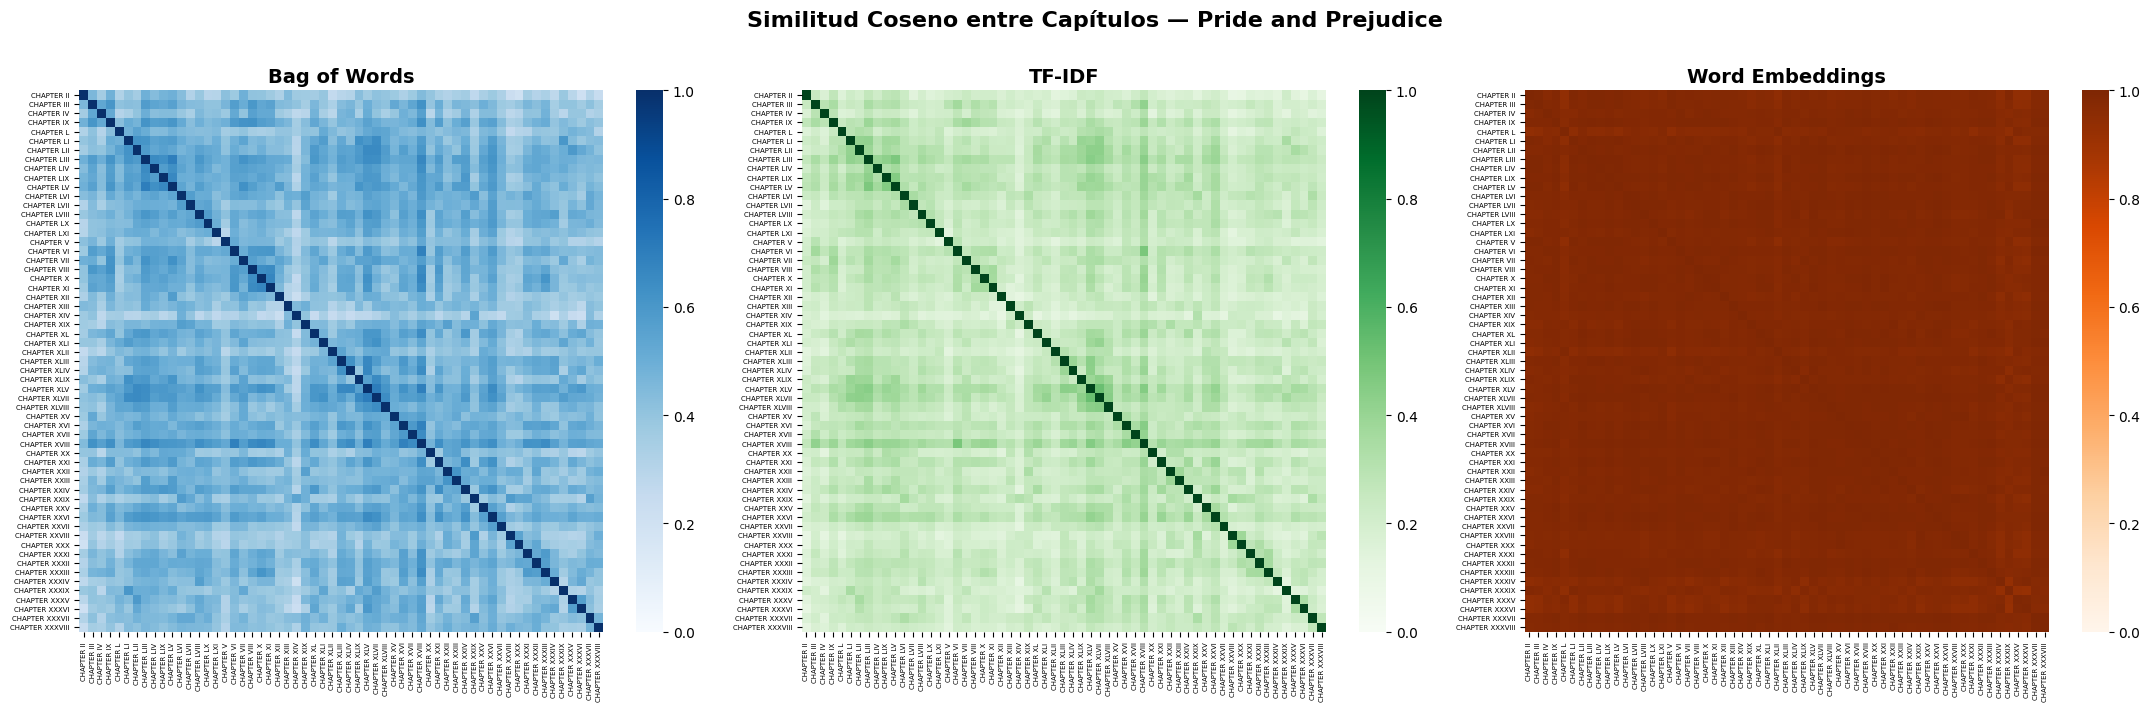

heatmap_similitud.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

configs = [
    (sim_bow,   "Bag of Words",   "Blues"),
    (sim_tfidf, "TF-IDF",         "Greens"),
    (sim_emb,   "Word Embeddings","Oranges"),
]

for ax, (matrix, title, cmap) in zip(axes, configs):
    sns.heatmap(matrix, ax=ax, cmap=cmap,
                xticklabels=chapters_list,
                yticklabels=chapters_list,
                vmin=0, vmax=1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=5)

plt.suptitle("Similitud Coseno entre Capítulos — Pride and Prejudice",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("heatmap_similitud.png", dpi=150, bbox_inches='tight')
plt.show()
print("heatmap_similitud.png")

In [31]:
def top_similar_pairs(sim_matrix, chapters, n=5, label=""):
    n_chap = len(chapters)
    pairs = []
    for i in range(n_chap):
        for j in range(i+1, n_chap):
            pairs.append((chapters[i], chapters[j], sim_matrix[i, j]))
    pairs.sort(key=lambda x: x[2], reverse=True)

    print(f"\n{'='*55}")
    print(f"  top {n} pares mas similares — {label}")
    print(f"{'='*55}")
    for a, b, score in pairs[:n]:
        print(f"  {a:20s} ↔ {b:20s}  sim={score:.4f}")
    return pairs

pairs_bow   = top_similar_pairs(sim_bow,   chapters_list, label="Bag of Words")
pairs_tfidf = top_similar_pairs(sim_tfidf, chapters_list, label="TF-IDF")
pairs_emb   = top_similar_pairs(sim_emb,   chapters_list, label="Word Embeddings")


  top 5 pares mas similares — Bag of Words
  CHAPTER XLV          ↔ CHAPTER XLVII         sim=0.7035
  CHAPTER LIII         ↔ CHAPTER LV            sim=0.6994
  CHAPTER XLV          ↔ CHAPTER XVIII         sim=0.6956
  CHAPTER XVI          ↔ CHAPTER XVIII         sim=0.6904
  CHAPTER VI           ↔ CHAPTER XVIII         sim=0.6900

  top 5 pares mas similares — TF-IDF
  CHAPTER XLV          ↔ CHAPTER XLVII         sim=0.5235
  CHAPTER VI           ↔ CHAPTER XVIII         sim=0.4820
  CHAPTER LIII         ↔ CHAPTER LV            sim=0.4732
  CHAPTER XLV          ↔ CHAPTER XVIII         sim=0.4556
  CHAPTER LIX          ↔ CHAPTER LV            sim=0.4552

  top 5 pares mas similares — Word Embeddings
  CHAPTER XL           ↔ CHAPTER XXIV          sim=0.9958
  CHAPTER XI           ↔ CHAPTER XVIII         sim=0.9953
  CHAPTER XLV          ↔ CHAPTER XXI           sim=0.9952
  CHAPTER XXI          ↔ CHAPTER XXVI          sim=0.9951
  CHAPTER XLV          ↔ CHAPTER XVIII         sim=0.9950


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

N_CLUSTERS = 5

# normalizar para KMeans
bow_norm = normalize(bow_matrix)
tfidf_norm = normalize(tfidf_matrix)
emb_norm = normalize(embeddings)

km_bow   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(bow_norm)
km_tfidf = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(tfidf_norm)
km_emb   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(emb_norm)

cluster_df = pd.DataFrame({
    'chapter':        chapters_list,
    'cluster_bow':    km_bow.labels_,
    'cluster_tfidf':  km_tfidf.labels_,
    'cluster_emb':    km_emb.labels_,
})

print("clusters por capitulo:")
print(cluster_df.to_string(index=False))

clusters por capitulo:
        chapter  cluster_bow  cluster_tfidf  cluster_emb
     CHAPTER II            2              2            4
    CHAPTER III            2              2            4
     CHAPTER IV            2              1            1
     CHAPTER IX            2              2            1
      CHAPTER L            4              4            2
     CHAPTER LI            4              4            4
    CHAPTER LII            4              4            1
   CHAPTER LIII            2              2            4
    CHAPTER LIV            2              2            4
    CHAPTER LIX            2              2            1
     CHAPTER LV            2              2            4
    CHAPTER LVI            0              0            1
   CHAPTER LVII            0              0            1
  CHAPTER LVIII            1              1            3
     CHAPTER LX            1              2            1
    CHAPTER LXI            1              2            1
      CH

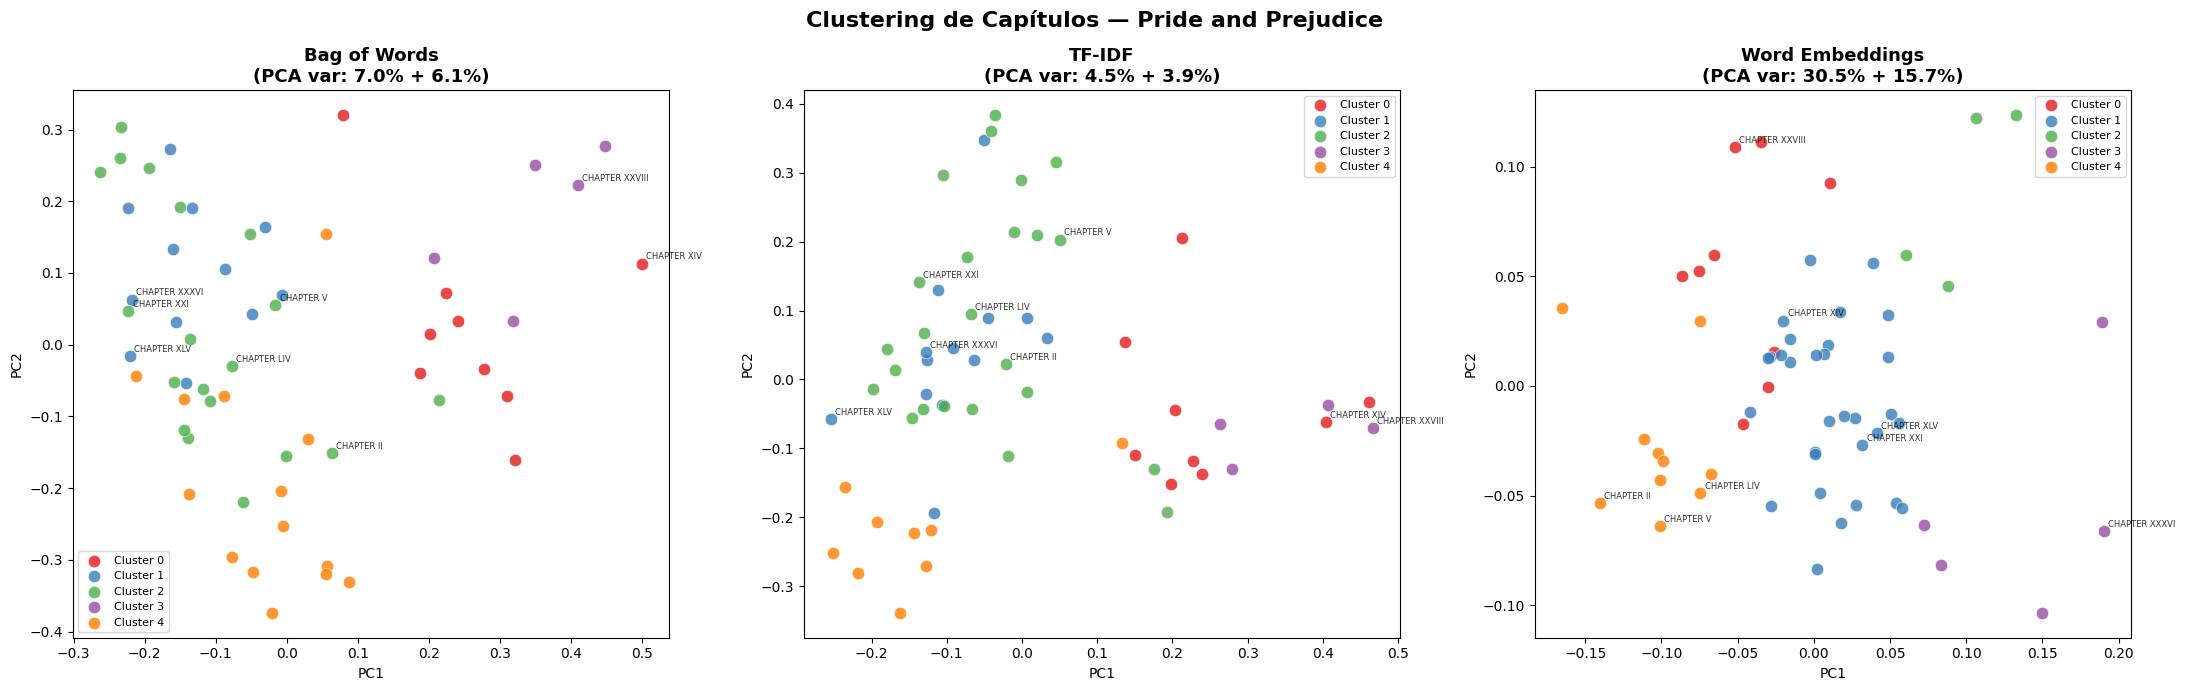

pca_clustering.png


In [33]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

datasets = [
    (bow_norm.toarray(),   km_bow.labels_,   "Bag of Words"),
    (tfidf_norm.toarray(), km_tfidf.labels_, "TF-IDF"),
    (emb_norm,             km_emb.labels_,   "Word Embeddings"),
]

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax, (data, labels, title) in zip(axes, datasets):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(data)
    var = pca.explained_variance_ratio_

    for cluster_id in range(N_CLUSTERS):
        mask = labels == cluster_id
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[cluster_id], label=f'Cluster {cluster_id}',
                   s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
    for i, chap in enumerate(chapters_list):
        if i % 8 == 0:
            ax.annotate(chap, (coords[i, 0], coords[i, 1]),
                        fontsize=6, alpha=0.8,
                        xytext=(3, 3), textcoords='offset points')

    ax.set_title(f"{title}\n(PCA var: {var[0]:.1%} + {var[1]:.1%})",
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Clustering de Capítulos — Pride and Prejudice",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("pca_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("pca_clustering.png")

In [34]:
# primeros 10 vs ultimos 10 capítulos
first_10 = list(range(10))
last_10  = list(range(len(chapters_list)-10, len(chapters_list)))

def avg_similarity(sim_matrix, idx_a, idx_b):
    vals = [sim_matrix[i, j] for i in idx_a for j in idx_b if i != j]
    return np.mean(vals)

print("similitud promedio — capitulos iniciales vs finales")
print(f"{'representacion':<20} {'Ini↔Ini':>10} {'Fin↔Fin':>10} {'Ini↔Fin':>10}")
print("-" * 52)
for label, sim in [("BoW", sim_bow), ("TF-IDF", sim_tfidf), ("embeddings", sim_emb)]:
    ii = avg_similarity(sim, first_10, first_10)
    ff = avg_similarity(sim, last_10,  last_10)
    if_ = avg_similarity(sim, first_10, last_10)
    print(f"{label:<20} {ii:>10.4f} {ff:>10.4f} {if_:>10.4f}")

similitud promedio — capitulos iniciales vs finales
representacion          Ini↔Ini    Fin↔Fin    Ini↔Fin
----------------------------------------------------
BoW                      0.4939     0.4302     0.4205
TF-IDF                   0.2851     0.2336     0.2256
embeddings               0.9814     0.9725     0.9760


In [35]:
import time
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_stem(text):
    tokens = word_tokenize(text)
    tokens = [t.lower() for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

def preprocess_lemma(text):
    tokens = word_tokenize(text)
    tokens = [t.lower() for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

ejemplos = [
    "Elizabeth was running quickly through the gardens, admiring the beautiful flowers.",
    "Mr. Darcy had been speaking very proudly to the assembled guests.",
    "The sisters were happily dancing at the grandest balls of the season.",
    "She looked at him with astonishment, her feelings utterly confused.",
]

print("=" * 75)
print(f"{'stemming vs lematizar':^75}")
print("=" * 75)

for oracion in ejemplos:
    stem_result  = preprocess_stem(oracion)
    lemma_result = preprocess_lemma(oracion)
    print(f"\noriginal  : {oracion}")
    print(f"   stemming  : {stem_result}")
    print(f"   lematiz.  : {lemma_result}")
    print("-" * 75)

                           stemming vs lematizar                           

original  : Elizabeth was running quickly through the gardens, admiring the beautiful flowers.
   stemming  : ['elizabeth', 'run', 'quickli', 'garden', 'admir', 'beauti', 'flower']
   lematiz.  : ['elizabeth', 'running', 'quickly', 'garden', 'admiring', 'beautiful', 'flower']
---------------------------------------------------------------------------

original  : Mr. Darcy had been speaking very proudly to the assembled guests.
   stemming  : ['darci', 'speak', 'proudli', 'assembl', 'guest']
   lematiz.  : ['darcy', 'speaking', 'proudly', 'assembled', 'guest']
---------------------------------------------------------------------------

original  : The sisters were happily dancing at the grandest balls of the season.
   stemming  : ['sister', 'happili', 'danc', 'grandest', 'ball', 'season']
   lematiz.  : ['sister', 'happily', 'dancing', 'grandest', 'ball', 'season']
--------------------------------------------

In [36]:
all_texts = df['text'].tolist()
stem_tokens_all  = [token for text in all_texts for token in preprocess_stem(text)]
lemma_tokens_all = [token for text in all_texts for token in preprocess_lemma(text)]

vocab_stem  = set(stem_tokens_all)
vocab_lemma = set(lemma_tokens_all)

print(f"  {'tecnica':<20} {'total tokens':>15} {'vocabulario unico':>18}")
print(f"  {'-'*55}")
print(f"  {'stemming':<20} {len(stem_tokens_all):>15,} {len(vocab_stem):>18,}")
print(f"  {'lematizacion':<20} {len(lemma_tokens_all):>15,} {len(vocab_lemma):>18,}")
print(f"\n  reduccion de vocab (stem vs lemma): "
      f"{len(vocab_lemma) - len(vocab_stem):+,} palabras")

print("\nejemplos de diferencias stem vs lemma:")
palabras_test = ['running','admiring','dancing','speaking','happily',
                 'feelings','studies','leaves','better','worse']
print(f"  {'palabra':<15} {'stem':>15} {'lemma':>15}")
print(f"  {'-'*45}")
for w in palabras_test:
    print(f"  {w:<15} {stemmer.stem(w):>15} {lemmatizer.lemmatize(w):>15}")

  tecnica                 total tokens  vocabulario unico
  -------------------------------------------------------
  stemming                      52,754              3,777
  lematizacion                  52,754              5,521

  reduccion de vocab (stem vs lemma): +1,744 palabras

ejemplos de diferencias stem vs lemma:
  palabra                    stem           lemma
  ---------------------------------------------
  running                     run         running
  admiring                  admir        admiring
  dancing                    danc         dancing
  speaking                  speak        speaking
  happily                 happili         happily
  feelings                   feel         feeling
  studies                   studi           study
  leaves                     leav            leaf
  better                   better          better
  worse                      wors           worse


In [37]:
import time
import tracemalloc

def medir_tiempo_memoria(func, data, label):
    # tiempo
    start = time.time()
    resultado = func(data)
    elapsed = time.time() - start

    # memoria
    tracemalloc.start()
    func(data)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"  {label:<30} {elapsed:.3f}s    {peak/1024:.1f} KB")
    return resultado

print("costos computacionales")
print(f"  {'tecnica':<30} {'tiempo':>8}    {'memoria pico':>12}")
print(f"  {'-'*55}")

texts = chapter_docs['processed_text'].tolist()

# Preprocesamiento
medir_tiempo_memoria(lambda d: [preprocess_stem(t)  for t in d], texts, "stemming (corpus)")
medir_tiempo_memoria(lambda d: [preprocess_lemma(t) for t in d], texts, "lematizacion (corpus)")

# Vectorización
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
medir_tiempo_memoria(lambda d: CountVectorizer().fit_transform(d),  texts, "Bag of Words")
medir_tiempo_memoria(lambda d: TfidfVectorizer().fit_transform(d),  texts, "TF-IDF")

# Embeddings
medir_tiempo_memoria(lambda d: np.array([get_embedding(t) for t in d]), texts, "Word Embeddings (spaCy)")

costos computacionales
  tecnica                          tiempo    memoria pico
  -------------------------------------------------------
  stemming (corpus)              1.192s    2866.3 KB
  lematizacion (corpus)          0.449s    2909.8 KB
  Bag of Words                   0.050s    1849.9 KB
  TF-IDF                         0.054s    1850.1 KB
  Word Embeddings (spaCy)        10.085s    40390.6 KB


array([[-0.71468353,  0.04545518, -0.18797432, ...,  0.05908795,
         0.04413487,  0.077603  ],
       [-0.7142139 ,  0.0518484 , -0.1745046 , ...,  0.03294098,
         0.03643607,  0.0471082 ],
       [-0.71171343,  0.08759878, -0.17052078, ...,  0.00123053,
         0.00290181,  0.06706967],
       ...,
       [-0.7219606 ,  0.09747417, -0.121053  , ...,  0.07267137,
         0.02517837,  0.04004255],
       [-0.7197667 ,  0.09663565, -0.140878  , ...,  0.01266653,
        -0.00311811,  0.0030828 ],
       [-0.71437216,  0.08922886, -0.13029908, ...,  0.02729671,
         0.01412621,  0.0249923 ]], dtype=float32)

In [38]:
import json

comparativa_tecnicas = []
for w in palabras_test:
    comparativa_tecnicas.append({
        "palabra_original": w,
        "stemming":         stemmer.stem(w),
        "lematizacion":     lemmatizer.lemmatize(w)
    })

resumen_vocab = {
    "stemming": {
        "total_tokens":    len(stem_tokens_all),
        "vocabulario_unico": len(vocab_stem)
    },
    "lematizacion": {
        "total_tokens":    len(lemma_tokens_all),
        "vocabulario_unico": len(vocab_lemma)
    }
}

with open("stemming_vs_lematizacion.json", "w", encoding="utf-8") as f:
    json.dump({
        "resumen_vocabulario": resumen_vocab,
        "comparativa_palabras": comparativa_tecnicas
    }, f, indent=2, ensure_ascii=False)

print("stemming_vs_lematizacion.json")

stemming_vs_lematizacion.json
